In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Lenovo\Downloads\employees.csv")
print(df)

     emp_id  dept_id           name department       city  education  \
0      1001        3   Rahul Sharma         HR  Hyderabad    Masters   
1      1002        4  Karthik Kumar  Marketing  Bangalore    Diploma   
2      1003        2  Karthik Reddy       Tech  Bangalore    Masters   
3      1004        2  Lakshmi Kumar       Tech    Chennai  Bachelors   
4      1005        3   Arjun Sharma         HR  Hyderabad    Masters   
..      ...      ...            ...        ...        ...        ...   
196    1197        1    Suresh Iyer      Sales    Chennai    Diploma   
197    1198        2      Deepa Rao       Tech    Chennai    Diploma   
198    1199        1    Rahul Kumar      Sales  Hyderabad  Bachelors   
199    1200        2    Kavya Singh       Tech    Chennai    Masters   
200    1021        1    Anita Patel      Sales       Pune    Masters   

        rating  experience   age  height_cm     salary   join_date  
0         Poor           4  53.0      169.5    47764.0  2018-01-03

In [2]:
age=df.age.dropna()
print("How many people:", len(age))
print("Average of age:", age.mean())
print("Middle Age:", age.median())

How many people: 200
Average of age: 38.175
Middle Age: 37.0


Matplotlib is a library which helps in plotting the graphs. It's compatible with numpy and pandas.
Pyplot is a part of matplotlib which helps for drawing.

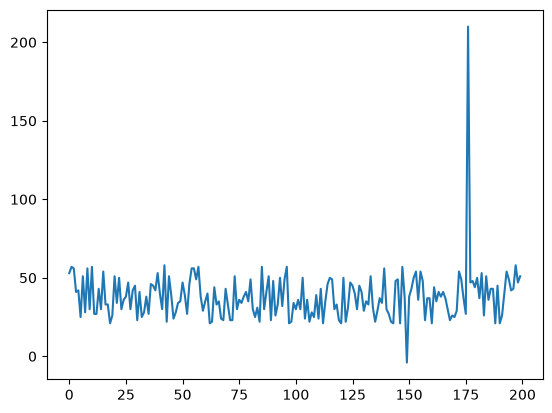

In [3]:
import matplotlib.pyplot as plt
plt.plot(age.values)
plt.show()

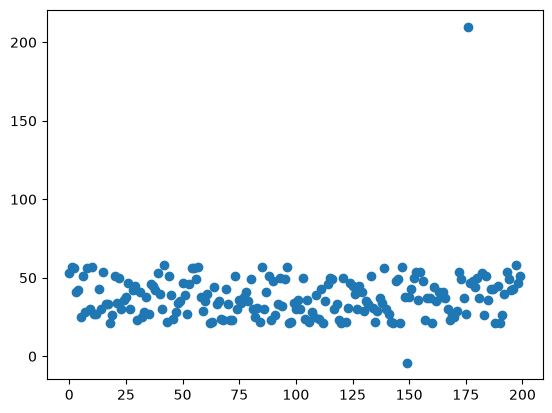

In [4]:
import matplotlib.pyplot as plt
plt.plot(age.values, "o")
plt.show()

Number just gave an assumption like everything is correct. But visualization will make it better to understand what is correct and what is incorrect.
Because the AGES are >200 and also <0 which is not possible.

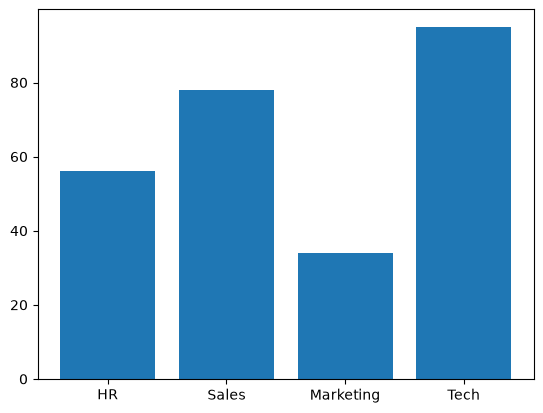

In [5]:
import matplotlib.pyplot as plt
plt.bar(["HR","Sales","Marketing","Tech"],[56,78,34,95])  #Takes two lists, x-axis and y-axis
plt.show()

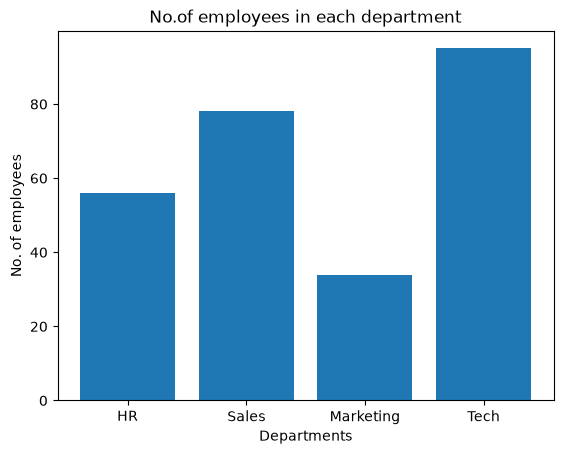

In [6]:
import matplotlib.pyplot as plt
plt.bar(["HR","Sales","Marketing","Tech"],[56,78,34,95])  #Takes two lists, x-axis and y-axis
plt.title("No.of employees in each department")
plt.xlabel("Departments")
plt.ylabel("No. of employees")
plt.show()

department
Sales        65
Tech         49
HR           45
Marketing    42
Name: count, dtype: int64


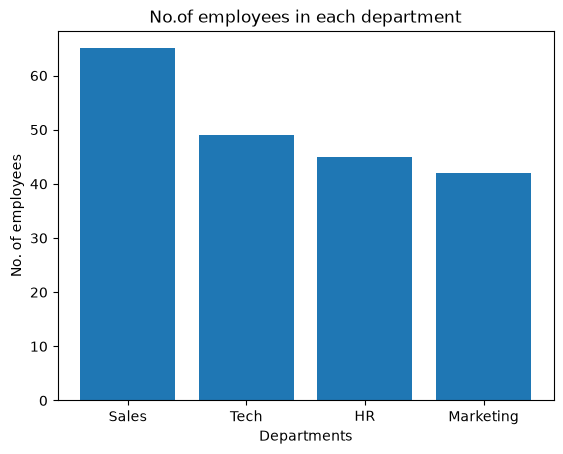

In [7]:
#Without hardcoding import the datas from the dataset

counts=df.department.value_counts()
print(counts)
plt.bar(counts.index,counts.values)
plt.title("No.of employees in each department")
plt.xlabel("Departments")
plt.ylabel("No. of employees")
plt.show()

In [10]:
sal= df.salary.dropna()  
print(len(sal), "salaries")

199 salaries


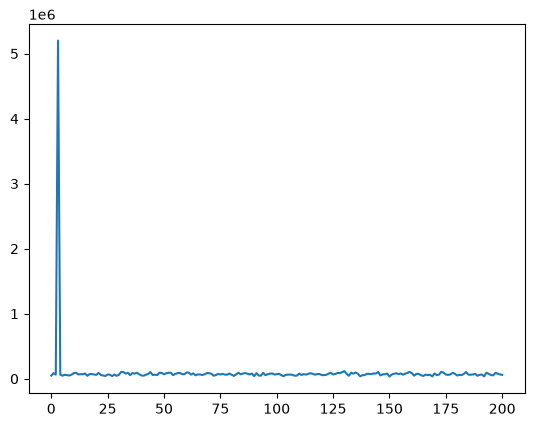

In [11]:
import matplotlib.pyplot as plt
plt.plot(sal)
plt.show()

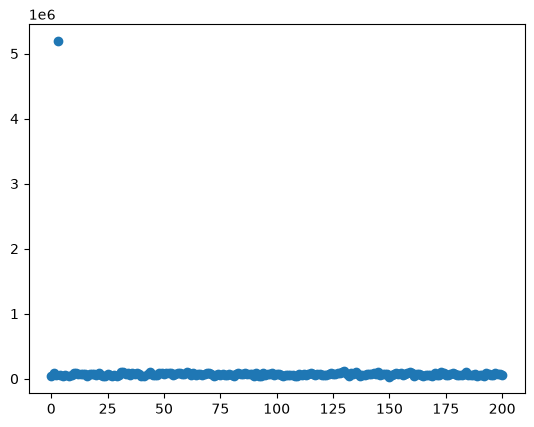

In [12]:
#The above graph doesnt convey anything to us, so use
plt.plot(sal, "o")
plt.show()

#In this graph we could only recognise one outlier, other than that nothing.

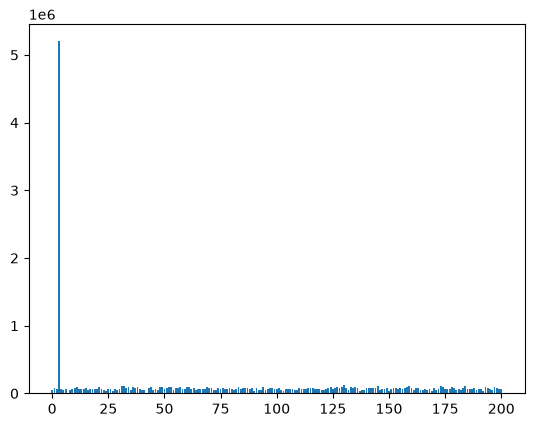

In [14]:
#So if we try to plot it in a bar graph we will get 200 different bars for each erson. 
plt.bar(sal.index,sal.values)
plt.show()

In [15]:
#So we should use HISTOGRAM for this
hr = df[df.department == "HR"].experience
print(len(hr),"employees")
print(sorted(hr))

45 employees
[0, 1, 1, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 6, 6, 7, 7, 7, 7, 7, 8, 8, 9, 9, 9, 9, 10, 10, 10, 11, 11, 11, 12, 13, 13, 13, 14, 14, 14, 15]


Bar graph: Based on the category, it helps us to identify how many people are there in that category
Histogram: Its ver good to play with the ranges. For example, exp with 0-3 yrs, 3-6 yrs, etc
0-3 yrs - 10 emp
4-7 yrs - 15 emp
8-11 yrs - 12 emp
12 - 15 yrs - 8 emp

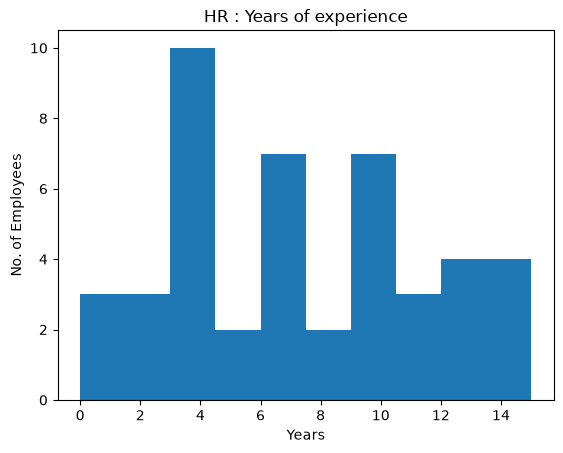

In [16]:
plt.hist(hr)
plt.title("HR : Years of experience")
plt.xlabel("Years")
plt.ylabel("No. of Employees")
plt.show()

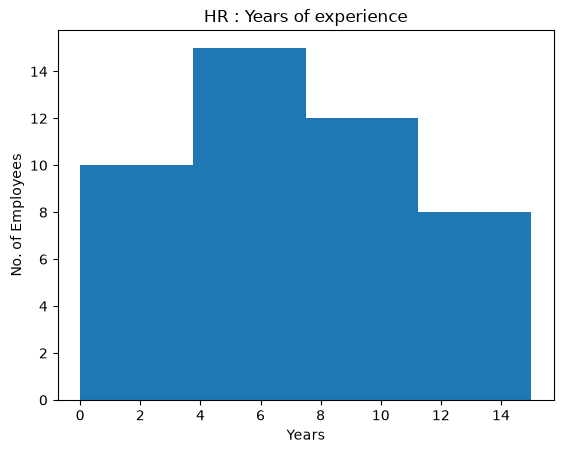

In [17]:
plt.hist(hr, bins = 4)   #Bins helps to separate the data into no.of ranges
plt.title("HR : Years of experience")
plt.xlabel("Years")
plt.ylabel("No. of Employees")
plt.show()

#In the bar graph there will be space in between, but in histogram it is continuous set of datas.


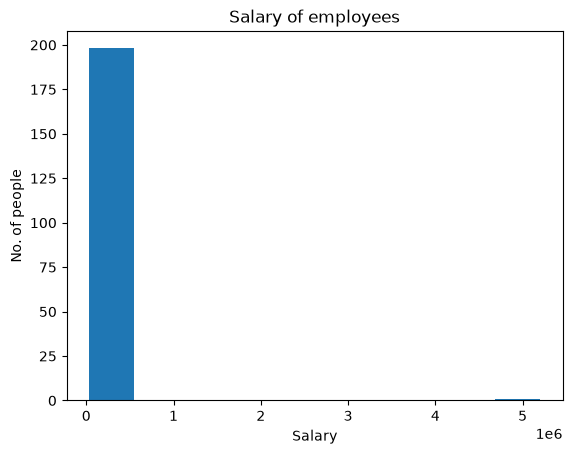

In [18]:
plt.hist(sal)
plt.title("Salary of employees")
plt.xlabel("Salary")
plt.ylabel("No. of people")
plt.show()

#This shows that 198 employees have the sal between 0-10 lakhs, and only one person have the salary of 52 lakhs.

In [24]:
#So remove the outliers using boxplot.

q1 = sal.quantile(0.25)
q3 = sal.quantile(0.75)
iqr=q3-q1

low = q1-1.5*iqr
high = q3+1.5*iqr

pop = sal[(sal>=low) & (sal<=high)] 
print(pop)  #Outliers are removed here

print("Q1:",q1, "Q3:",q3, "IQR:", iqr)

print("Fences:", low, "to", "high")
print(len(pop), "of", len(sal))
print(pop.skew())  #Almost is equal to 0

0      47764.0
1      86052.0
2      62990.0
4      62556.0
5      47111.0
        ...   
196    51904.0
197    89980.0
198    78169.0
199    66075.0
200    59760.0
Name: salary, Length: 197, dtype: float64
Q1: 59003.5 Q3: 80599.5 IQR: 21596.0
Fences: 26609.5 to high
197 of 199
0.10250002673395041


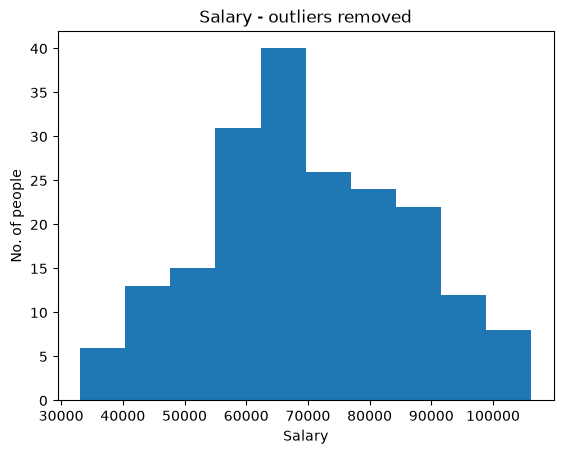

In [27]:
plt.hist(pop)
plt.title("Salary - outliers removed")
plt.xlabel("Salary")
plt.ylabel("No. of people")
plt.show()

#Now if we draw the curve, it would be symmetrical - bell curve as the outliers are removed.
#Bins helps us to decide how much we need to split the data intpo, or how many ranges to make. Based on that how we need the data tolook, we should mention the no.of bins

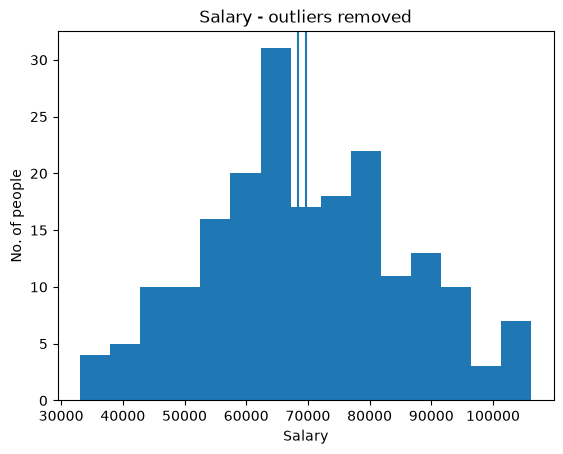

In [29]:
plt.hist(pop, bins = 15)
plt.axvline(pop.mean())
plt.axvline(pop.median())
plt.title("Salary - outliers removed")
plt.xlabel("Salary")
plt.ylabel("No. of people")
plt.show()

#Two lines will be printed, for mean() and median() but we dont know which line is mean and which line is median. So use color

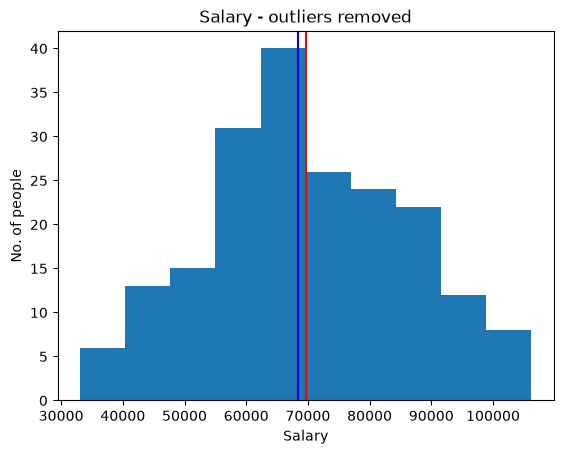

In [40]:
plt.hist(pop, bins = 10)
plt.axvline(pop.mean(),color="red")
plt.axvline(pop.median(), color="blue")
plt.title("Salary - outliers removed")
plt.xlabel("Salary")
plt.ylabel("No. of people")
plt.show()

#Mean > Median (Right Skew)

In [31]:
#Similarly if we need to do the above the same for each dept separately, Then we can do it by boxplot.
print("Minimum:", sal.min())
print("Maximum:", sal.max())
print("Mean:", sal.mean())
print("Median:", sal.median())
print("25% :", sal.quantile(0.25))
print("75% :", sal.quantile(0.75))

Minimum: 33085.0
Maximum: 5200000.0
Mean: 95648.40703517589
Median: 68647.0
25% : 59003.5
75% : 80599.5


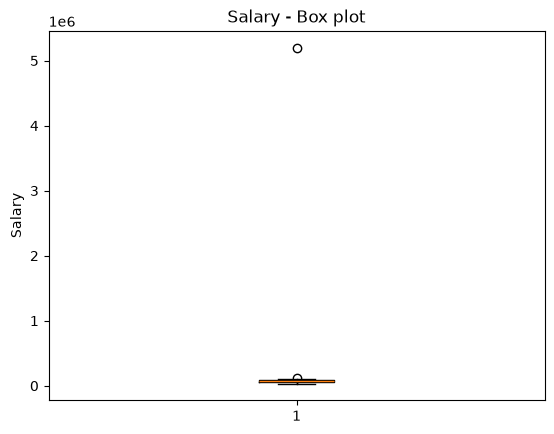

In [33]:
plt.boxplot(sal)
plt.title("Salary - Box plot")
plt.ylabel("Salary")
plt.show()

#Here, we used original salary and not the cleaned salary, also no department segregation done, all dept together. We can see 2 circles and those are outliers.

In [35]:
clean=df[(df["salary"]>=low) & (df["salary"]<=high)]
print(clean)    

     emp_id  dept_id           name department       city  education  \
0      1001        3   Rahul Sharma         HR  Hyderabad    Masters   
1      1002        4  Karthik Kumar  Marketing  Bangalore    Diploma   
2      1003        2  Karthik Reddy       Tech  Bangalore    Masters   
4      1005        3   Arjun Sharma         HR  Hyderabad    Masters   
5      1006        1    Sneha Reddy      Sales       Pune  Bachelors   
..      ...      ...            ...        ...        ...        ...   
196    1197        1    Suresh Iyer      Sales    Chennai    Diploma   
197    1198        2      Deepa Rao       Tech    Chennai    Diploma   
198    1199        1    Rahul Kumar      Sales  Hyderabad  Bachelors   
199    1200        2    Kavya Singh       Tech    Chennai    Masters   
200    1021        1    Anita Patel      Sales       Pune    Masters   

        rating  experience   age  height_cm   salary   join_date  
0         Poor           4  53.0      169.5  47764.0  2018-01-03  
1

{'whiskers': [<matplotlib.lines.Line2D at 0x2860f570fd0>,
 'caps': [<matplotlib.lines.Line2D at 0x2860f571290>,
 'boxes': [<matplotlib.lines.Line2D at 0x2860f571990>],
 'medians': [<matplotlib.lines.Line2D at 0x2860f5d0590>],
 'fliers': [<matplotlib.lines.Line2D at 0x2860f5d0d90>],
 'means': []}

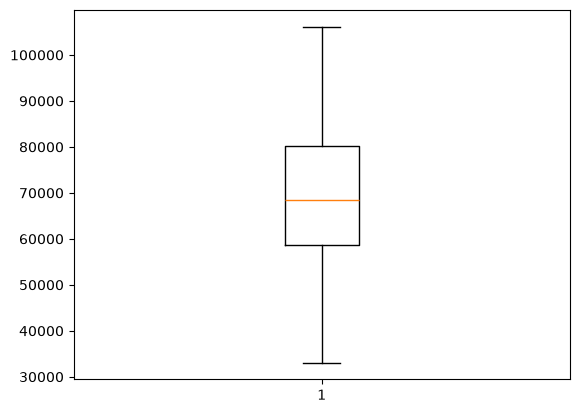

In [36]:
plt.boxplot(pop)

#Now the plot we got is the boxplot for all the dept together
# Now we need it for each dept separately

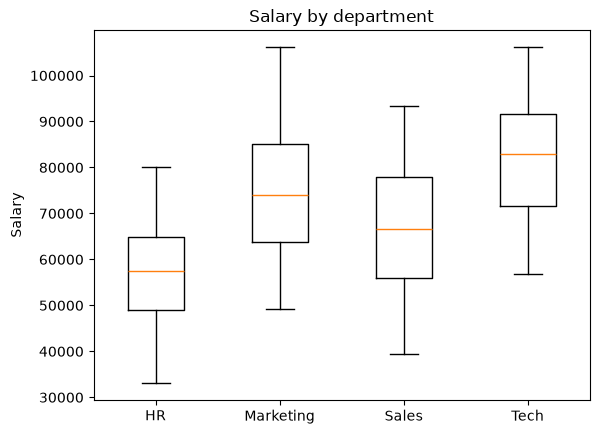

In [39]:
orders=["HR","Marketing","Sales","Tech"]
groups=[]
for d in orders:
    groups.append(clean[clean["department"]==d]["salary"])
plt.boxplot(groups,tick_labels=orders)
plt.title("Salary by department")
plt.ylabel("Salary")
plt.show()

HISTOGRAM                           

One column,in detail
shows the SHAPE
you choose the bins
one at a time

BOX PLOT
one column, as 5 numbers
shows outliers as dots
you choose nothing
several side by side